In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
pd.set_option('display.max_columns', None)

In [2]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

In [3]:
train_values = pd.read_csv(DATA_DIR / "train_values.csv", index_col="sequence_id")
train_labels = pd.read_csv(DATA_DIR / "train_labels.csv", index_col="sequence_id")

In [4]:
train_values.columns

Index(['sequence', 'bacterial_resistance_ampicillin',
       'bacterial_resistance_chloramphenicol',
       'bacterial_resistance_kanamycin', 'bacterial_resistance_other',
       'bacterial_resistance_spectinomycin', 'copy_number_high_copy',
       'copy_number_low_copy', 'copy_number_unknown',
       'growth_strain_ccdb_survival', 'growth_strain_dh10b',
       'growth_strain_dh5alpha', 'growth_strain_neb_stable',
       'growth_strain_other', 'growth_strain_stbl3', 'growth_strain_top10',
       'growth_strain_xl1_blue', 'growth_temp_30', 'growth_temp_37',
       'growth_temp_other', 'selectable_markers_blasticidin',
       'selectable_markers_his3', 'selectable_markers_hygromycin',
       'selectable_markers_leu2', 'selectable_markers_neomycin',
       'selectable_markers_other', 'selectable_markers_puromycin',
       'selectable_markers_trp1', 'selectable_markers_ura3',
       'selectable_markers_zeocin', 'species_budding_yeast', 'species_fly',
       'species_human', 'species_mouse'

In [5]:
train_values.sequence.str.len().describe()

count    63017.000000
mean      4839.025501
std       3883.148431
min         20.000000
25%        909.000000
50%       4741.000000
75%       7490.000000
max      60099.000000
Name: sequence, dtype: float64

In [6]:
train_values.sequence.str.len().quantile([0.90, 0.95, 0.99, 0.999])

0.900     9437.400
0.950    11101.000
0.990    15807.840
0.999    22645.984
Name: sequence, dtype: float64

In [7]:
print((train_values.sequence.str.len()< 100).sum())
print((train_values.sequence.str.len()< 500).sum())
print((train_values.sequence.str.len() < 1000).sum())

26
589
19543


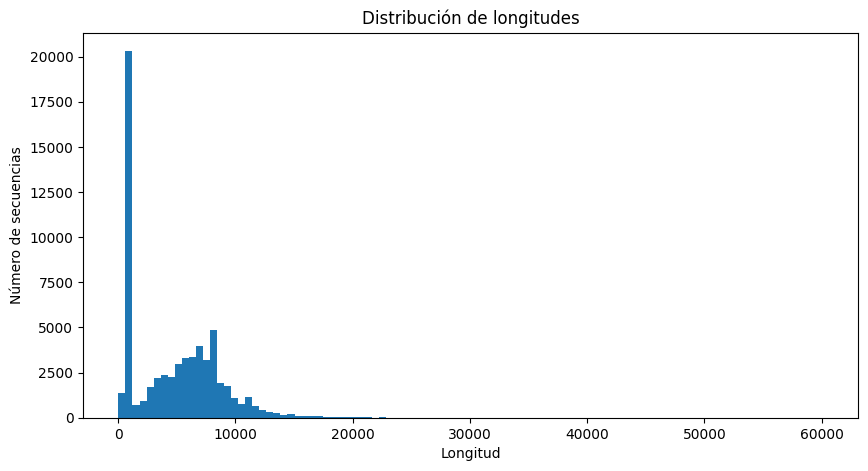

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(train_values.sequence.str.len(), bins=100)
plt.xlabel("Longitud")
plt.ylabel("Número de secuencias")
plt.title("Distribución de longitudes")
plt.show()

In [9]:
len(train_values)

63017

In [10]:
train_values.shape

(63017, 40)

In [11]:
len(train_labels)

63017

In [12]:
lab_ids = pd.DataFrame(train_labels.idxmax(axis=1), columns=["lab_id"])

In [13]:
len(lab_ids)

63017

In [14]:
train_dff = train_values.join(lab_ids)

In [15]:
train_dff.shape

(63017, 41)

In [16]:
train_dff.columns

Index(['sequence', 'bacterial_resistance_ampicillin',
       'bacterial_resistance_chloramphenicol',
       'bacterial_resistance_kanamycin', 'bacterial_resistance_other',
       'bacterial_resistance_spectinomycin', 'copy_number_high_copy',
       'copy_number_low_copy', 'copy_number_unknown',
       'growth_strain_ccdb_survival', 'growth_strain_dh10b',
       'growth_strain_dh5alpha', 'growth_strain_neb_stable',
       'growth_strain_other', 'growth_strain_stbl3', 'growth_strain_top10',
       'growth_strain_xl1_blue', 'growth_temp_30', 'growth_temp_37',
       'growth_temp_other', 'selectable_markers_blasticidin',
       'selectable_markers_his3', 'selectable_markers_hygromycin',
       'selectable_markers_leu2', 'selectable_markers_neomycin',
       'selectable_markers_other', 'selectable_markers_puromycin',
       'selectable_markers_trp1', 'selectable_markers_ura3',
       'selectable_markers_zeocin', 'species_budding_yeast', 'species_fly',
       'species_human', 'species_mouse'

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder.fit(train_dff["lab_id"])

train_dff["lab_id"] = label_encoder.transform(train_dff["lab_id"])

In [18]:
from sklearn.model_selection import train_test_split

train_df, validation_df = train_test_split(
    train_dff,
    test_size=0.2,
    random_state=42
)

In [19]:
label_encoder.inverse_transform([8])

array(['0B9GCUVV'], dtype=object)

In [20]:
print(train_df.shape)
print(validation_df.shape)


(50413, 41)
(12604, 41)


In [21]:
import pandas as pd

def create_window_dataset(df, window_size=1000, stride=500, pad_char="N"):
    rows = []

    for idx, row in df.iterrows():
        sequence = row["sequence"]

        # Recorremos la secuencia con una ventana deslizante
        for start in range(0, len(sequence), stride):
            window = sequence[start:start + window_size]

            # Si la ventana quedó incompleta, hacemos padding
            if len(window) < window_size:
                window = window + pad_char * (window_size - len(window))

            # Copiamos toda la fila
            new_row = row.copy()

            # Reemplazamos únicamente la secuencia
            new_row["sequence"] = window

            # Guardamos información útil
            new_row["window_start"] = start
            new_row["window_end"] = min(start + window_size, len(sequence))

            rows.append(new_row)

            # Si ya llegamos al final, terminamos
            if start + window_size >= len(sequence):
                break

    return pd.DataFrame(rows)

In [22]:
train_windows = create_window_dataset(
    train_df,
    window_size=1000,
    stride=500
)

In [23]:
val_windows = create_window_dataset(
    validation_df,
    window_size=1000,
    stride=500
)

In [24]:
print(train_windows.shape)
print(val_windows.shape)

(460923, 43)
(115431, 43)


In [25]:
# Separar datos de entrenamiento
X_sequence = train_windows["sequence"].values

X_metadata = (
    train_windows
    .drop(columns=["sequence", "lab_id",'window_start', 'window_end'])
    .astype(np.float32)
    .values
)

# Convertir etiquetas a enteros
y = train_windows['lab_id']

In [26]:
print(X_sequence.shape)
print(X_metadata.shape)
print(y.shape)

(460923,)
(460923, 39)
(460923,)


In [27]:
# Separar datos de validación
X_sequence_val = val_windows["sequence"].values

X_metadata_val = (
    val_windows
    .drop(columns=["sequence", "lab_id",'window_start', 'window_end'])
    .astype(np.float32)
    .values
)

# Convertir etiquetas a enteros
y_val = val_windows['lab_id']

In [28]:
print(X_sequence_val.shape)
print(X_metadata_val.shape)
print(y_val.shape)

(115431,)
(115431, 39)
(115431,)


In [29]:
import tensorflow as tf
import numpy as np

In [30]:
# Crear Dataset
dataset = tf.data.Dataset.from_tensor_slices(
    (X_sequence, X_metadata, y)
)

In [31]:
# Crear Dataset
dataset_val = tf.data.Dataset.from_tensor_slices(
    (X_sequence_val, X_metadata_val, y_val)
)

In [32]:
# Tabla de conversión de nucleótidos
keys = tf.constant(["A", "C", "G", "T", "N"])
values = tf.constant([0, 1, 2, 3, 4])

lookup_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values),
    default_value=4
)

In [33]:
# Función de codificación
def encode(sequence, metadata, label):

    bases = tf.strings.bytes_split(sequence)

    indices = lookup_table.lookup(bases)

    sequence = tf.one_hot(
        indices,
        depth=5,
        dtype=tf.float32
    )

    return (sequence, metadata), label

In [34]:
# ENTRENAMIENTO
# Aplicar la codificación
dataset = dataset.map(
    encode,
    num_parallel_calls=tf.data.AUTOTUNE
)
# Agrupar en lotes
dataset = dataset.batch(32)

# Preparar el siguiente lote mientras se entrena el actual
dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [35]:
# VALIDACION
# Aplicar la codificación
dataset_val = dataset_val.map(
    encode,
    num_parallel_calls=tf.data.AUTOTUNE
)
# Agrupar en lotes
dataset_val = dataset_val.batch(32)

# Preparar el siguiente lote mientras se entrena el actual
dataset_val = dataset_val.prefetch(tf.data.AUTOTUNE)

In [36]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate
)

# Entrada de secuencias
sequence_input = Input(shape=(1000, 5), name="sequence")

x = Conv1D(64, 15, activation="relu", padding="same")(sequence_input)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(128, 7, activation="relu", padding="same")(x)
x = GlobalMaxPooling1D()(x)

# Entrada de metadatos
metadata_input = Input(shape=(39,), name="metadata")

m = Dense(64, activation="relu")(metadata_input)

# Unir ambas ramas
combined = Concatenate()([x, m])

combined = Dense(128, activation="relu")(combined)
combined = Dropout(0.3)(combined)

# Salida
output = Dense(1314, activation="softmax")(combined)

# Modelo
model = Model(
    inputs=[sequence_input, metadata_input],
    outputs=output
)


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=10, name="top10_accuracy")
    ]
)


In [37]:
# Resumen
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 1000, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 64)  │      4,864 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 500, 64)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 128)  │     57,472 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,560 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1314)      │    169,506 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 259,106 (1012.13 KB)

 Trainable params: 259,106 (1012.13 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = model.fit(
    dataset,
    validation_data=dataset_val,
    epochs=10
)

Epoch 1/10
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 607s 42ms/step - accuracy: 0.3294 - loss: 4.0801 - top10_accuracy: 0.5691 - val_accuracy: 0.3931 - val_loss: 3.2108 - val_top10_accuracy: 0.6892
Epoch 2/10
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 653s 45ms/step - accuracy: 0.4084 - loss: 2.9022 - top10_accuracy: 0.7161 - val_accuracy: 0.4246 - val_loss: 2.8980 - val_top10_accuracy: 0.7380
Epoch 3/10
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 738s 51ms/step - accuracy: 0.4320 - loss: 2.6304 - top10_accuracy: 0.7573 - val_accuracy: 0.4390 - val_loss: 2.8180 - val_top10_accuracy: 0.7540
Epoch 4/10
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 768s 53ms/step - accuracy: 0.4454 - loss: 2.5064 - top10_accuracy: 0.7757 - val_accuracy: 0.4508 - val_loss: 2.7879 - val_top10_accuracy: 0.7613
Epoch 5/10
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 808s 56ms/step - accuracy: 0.4554 - loss: 2.4319 - top10_accuracy: 0.7862 - val_accuracy: 0.4604 - val_loss: 2.7507 - val_top10_accuracy: 0.7709
Epoch 6/10
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 1012s 70ms/

In [43]:
model.save("../models/modelo_01_CNN_10Epochs.keras")


In [39]:
results = model.evaluate(dataset_val)


3608/3608 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - accuracy: 0.4632 - loss: 2.8198 - top10_accuracy: 0.7795


In [40]:
predictions = model.predict(dataset_val)

3608/3608 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step


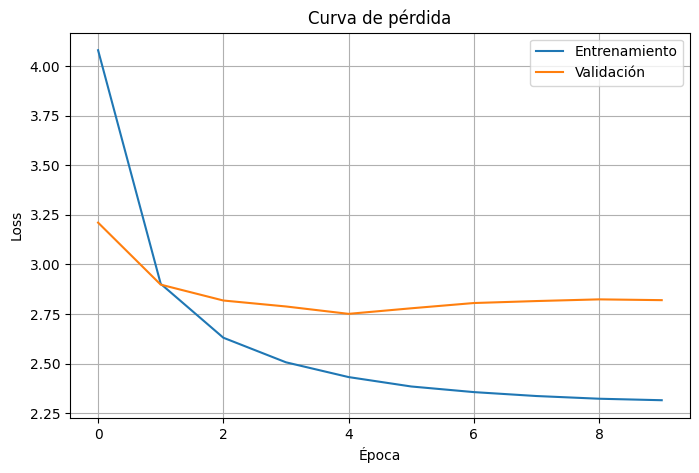

In [41]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.grid(True)
plt.show()

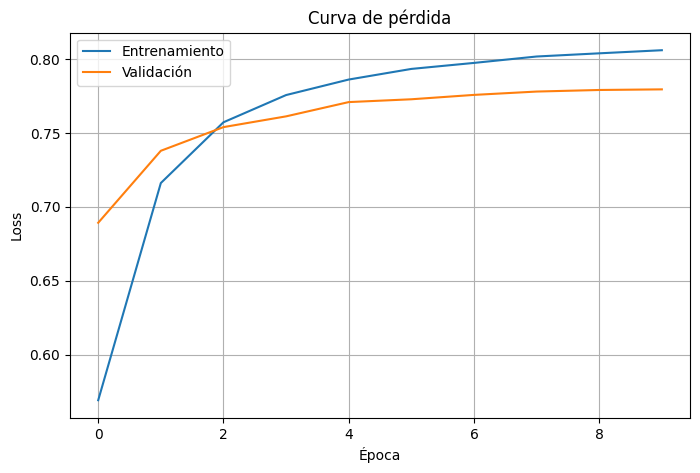

In [ ]:
import matplotlib.pyplot as plt

# top10_accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['top10_accuracy'], label='Entrenamiento')
plt.plot(history.history['val_top10_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('top10_accuracy')
plt.title('Curva de top10_accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import json

with open("../models/history_modelo_01.json", "w") as f:
    json.dump(history.history, f)

In [44]:
history2 = model.fit(
    dataset,
    validation_data=dataset_val,
    initial_epoch=10,
    epochs=15
)

Epoch 11/15
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 831s 58ms/step - accuracy: 0.4695 - loss: 2.3118 - top10_accuracy: 0.8068 - val_accuracy: 0.4667 - val_loss: 2.8579 - val_top10_accuracy: 0.7815
Epoch 12/15
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 1274s 88ms/step - accuracy: 0.4689 - loss: 2.3188 - top10_accuracy: 0.8071 - val_accuracy: 0.4589 - val_loss: 2.9045 - val_top10_accuracy: 0.7751
Epoch 13/15
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 2775s 193ms/step - accuracy: 0.4672 - loss: 2.3240 - top10_accuracy: 0.8071 - val_accuracy: 0.4627 - val_loss: 2.9262 - val_top10_accuracy: 0.7785
Epoch 14/15
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 1306s 91ms/step - accuracy: 0.4669 - loss: 2.3287 - top10_accuracy: 0.8065 - val_accuracy: 0.4624 - val_loss: 2.9784 - val_top10_accuracy: 0.7771
Epoch 15/15
14404/14404 ━━━━━━━━━━━━━━━━━━━━ 1341s 93ms/step - accuracy: 0.4646 - loss: 2.3428 - top10_accuracy: 0.8058 - val_accuracy: 0.4659 - val_loss: 2.9685 - val_top10_accuracy: 0.7764


In [ ]:
model.save("../models/modelo_02_CNN_15Epochs.keras")


In [ ]:
import json

with open("../models/history_modelo_02.json", "w") as f:
    json.dump(history2.history, f)

In [48]:
history_total = {}

for key in history.history:
    history_total[key] = history.history[key] + history2.history[key]

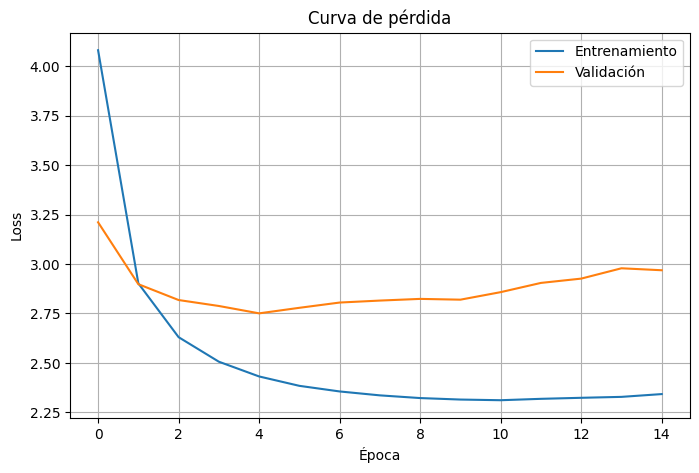

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_total['loss'], label='Entrenamiento')
plt.plot(history_total['val_loss'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.grid(True)
plt.show()

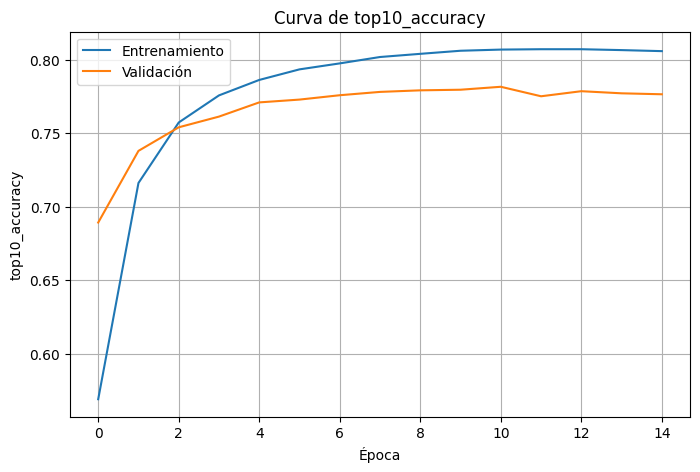

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_total['top10_accuracy'], label='Entrenamiento')
plt.plot(history_total['val_top10_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('top10_accuracy')
plt.title('Curva de top10_accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import json

with open("history.json", "r") as f:
    history_dict = json.load(f)